   
Дискретный ряд:
   
| Значение варианты (x) | Частота (n) |
   
|    14| 49|
|    15| 53|
|    16| 236|
|    17| 126|
|    18| 806|
|    19| 971|
|    20| 910|
|    21| 716|
|    22| 944|
|    23| 1071|
|    24| 810|
|    25| 1050|
|    26| 980|
|    27| 1263|
|    28| 1113|
|    29| 1340|
|    30| 734|
|    31| 1115|
|    32| 796|
|    33| 758|
|    34| 869|
|    35| 676|
|    36| 1198|
|    37| 522|
|    38| 1006|
|    39| 695|
|    40| 723|
|    41| 837|
|    42| 978|
|    43| 820|
|    44| 1032|
|    45| 690|
|    46| 677|
|    47| 831|
|    48| 1026|
|    49| 1060|
|    50| 150|
|    51| 188|
|    52| 193|
|    53| 47|
|    54| 26|
|    55| 62|
|    56| 76|
|    57| 136|
|    58| 262|
|    59| 74|
|    60| 266|
|    61| 226|
|    62| 139|
|    63| 183|
|    64| 189|
|    65| 79|
|    66| 188|
|    67| 128|
|    69| 202|
|    70| 26|
|    71| 85|
|    73| 17|
    ---    
  | Итого | 32423 |
    ---    
Интервальный ряд
    ---    
min = 14, max = 73, количество групп(k) = 7, дл

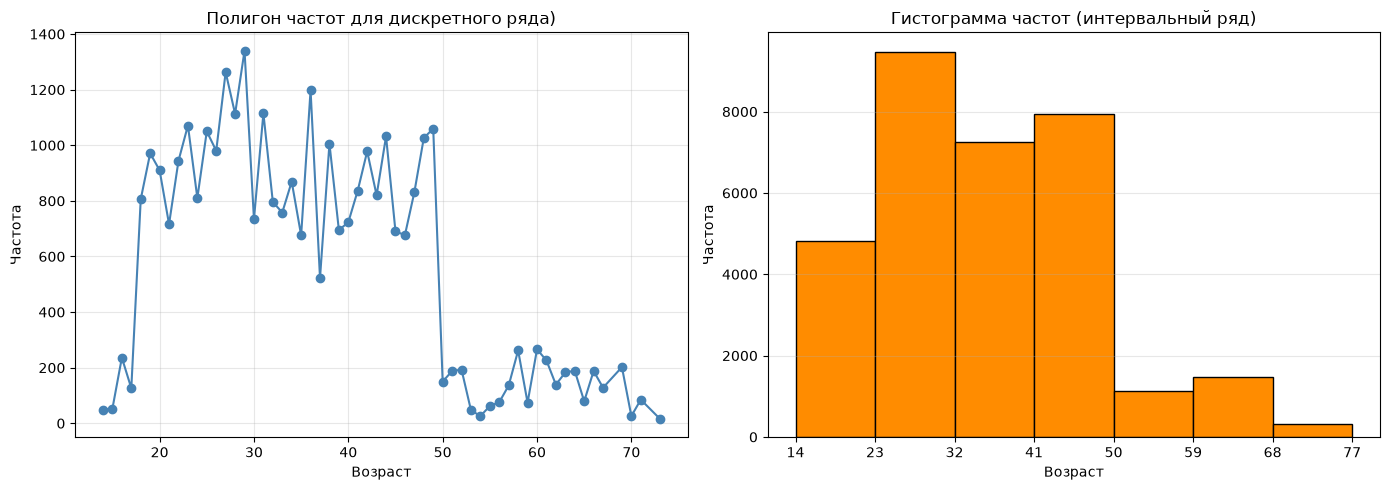

In [2]:
# py -m pip install matplotlib
#Библиотеки
from math import ceil
from pathlib import Path # Библиотека для работы с файлами и их адресами
from collections import Counter #
import math # Библиотка для математический действий
import matplotlib.pyplot as plt # библиотека для рисования графико и диаграмм в в питоне.


# Функция для вычисления коэффициентов дискретного ряда
def Calc_Discretny(numbers):
    sn = sorted(set(numbers)) # Отсортированный список без повторений элементов
    N = 0 # Сумма частот
    x_midl = 0 # Среднее +
    moda = 0 # Мода +
    r = float("-inf")# Частота моды + 
    mediana = 0 # медиана + 
    mi = min(sn) # минимум +
    ma = max(sn) # максимум +
    razmah = ma - mi # размах +
    for i in sn:
        n = numbers.count(i) # кол. элемента
        x_midl += i * n # высчитываем сумму среднего, но пока без деления на сумму частот
        N+= n
        if(n > r):
            moda = i
            r = n
    x_midl /= N

    #Высчитывание медианы
    half = N / 2 # индекс медианы
    sbor = 0 # накопленная частота
    mediana = 0 # Запись медианы
    for i in sn:
        sbor += numbers.count(i)
        if sbor >= half:
            mediana = i
            break
    print("  ")

    print (f"Среднее: {x_midl}")
    print (f"Мода: {moda} с частотой {r}")
    print (f"Медиана: {mediana}")
    print (f"Минимум: {mi}; Максимум: {ma}; Размах: {razmah}")
    Dispersia(x_midl, sn, numbers, N)

#Функция для вычисления дисперсии и зависщих от ее значения стат. харак. (для дискретного ряда)
def Dispersia (x_midl, sn, numbers, N):
     D = 0
     for i in sn:
        D += (i - x_midl)**2 * numbers.count(i)
     D = D / N # Дисперсия
     d = math.sqrt(D) # среднее квадратичное отклонение
     v_x = d / x_midl * 100 # коэфф. вариации в процентах
     print (f"Дисперсия: {D}")
     print (f"Cреднее квадратичное отклонение: {d}")
     print (f"Коэфф. вариации: {v_x}%")

# Функция для вычисления коэффициентов интервального ряда
# В отличие от дискретного ряда, здесь известны только середины интервалов
# и их частоты, поэтому моду и медиану нельзя брать "в лоб" - их находят
# интерполяцией внутри модального/медианного интервала.
def Calc_Interval(mids, int_f, Edges, h):
    N = sum(int_f) # Сумма частот
    x_midl = 0 # Среднее
    for i in range(len(mids)):
        x_midl += mids[i] * int_f[i]
    x_midl /= N

    # Поиск модального интервала (с наибольшей частотой)
    mo_i = 0
    r = int_f[0]
    for i in range(len(int_f)):
        if int_f[i] > r:
            r = int_f[i]
            mo_i = i
    f_prev = int_f[mo_i - 1] if mo_i > 0 else 0
    f_next = int_f[mo_i + 1] if mo_i < len(int_f) - 1 else 0
    if (r - f_prev) + (r - f_next) == 0:
        moda = mids[mo_i]
    else:
        moda = Edges[mo_i] + h * (r - f_prev) / ((r - f_prev) + (r - f_next))

    # Поиск медианного интервала по накопленной частоте
    half = N / 2 # индекс медианы
    sbor = 0 # накопленная частота
    mediana = 0
    for i in range(len(int_f)):
        prev_sbor = sbor
        sbor += int_f[i]
        if sbor >= half:
            mediana = Edges[i] + h * (half - prev_sbor) / int_f[i]
            break

    mi = Edges[0] # минимум - левая граница первого интервала
    ma = Edges[-1] # максимум - правая граница последнего интервала
    razmah = ma - mi # размах
    print("  ")

    print (f"Среднее: {x_midl}")
    print (f"Мода: {moda} с модальной частотой {r}")
    print (f"Медиана: {mediana}")
    print (f"Минимум: {mi}; Максимум: {ma}; Размах: {razmah}")
    Dispersia_interval(x_midl, mids, int_f, N)

#Функция для вычисления дисперсии и зависщих от ее значения стат. харак. (для интервального ряда)
def Dispersia_interval(x_midl, mids, int_f, N):
     D = 0
     for i in range(len(mids)):
        D += (mids[i] - x_midl)**2 * int_f[i]
     D = D / N # Дисперсия
     d = math.sqrt(D) # среднее квадратичное отклонение
     v_x = d / x_midl * 100 # коэфф. вариации в процентах
     print (f"Дисперсия: {D}")
     print (f"Cреднее квадратичное отклонение: {d}")
     print (f"Коэфф. вариации: {v_x}%")

#Раздел 1. Ряды распределения и интервалы с последующими .
# Читаем путь к файлу
fp = Path("./Москва_2021.txt") 
# Дискретный ряд
if fp.exists():
    with open(fp, "r", encoding="utf-8") as f: # Открыть и прочитать файл, на любом языке с переменной файла f
        numbers = sorted([int(line.strip()) for line in f if line.strip()])
    
    print("   ")
    print("Дискретный ряд:")
    print("   ")
    print(f"| {'Значение варианты (x)':>12} | {'Частота (n)':>11} |")
    print("   ")

    counts = Counter(numbers)              # считаем частоты с помощью counter
    discret_val = sorted(counts.keys())         # уникальные значения по возрастанию
    disc_list_of_n = [counts[v] for v in discret_val]
    for val in discret_val:
        print(f"|    {val}| {counts[val]}|")
    print("    ---    ")
    print(f"  | {'Итого'} | {sum(counts.values())} |")

    # Интервальный ряд из 7 групп:
    x_min = min(numbers)
    x_max = max(numbers)
    k = 7
    h = int(ceil((x_max - x_min) / k)) # длина одного интервала

    print("    ---    ")
    print("Интервальный ряд")
    print("    ---    ")
    print(f"min = {x_min}, max = {x_max}, количество групп(k) = {k}, длина интервалов групп(h) = {h:.4f}")
    print("   ")
    print(f"| {'№':>2} | {'Интервал':>18} | {'Середина':>9} | {'Частота':>8} |")

    # границы интервалов
    Edges = [x_min + i * h for i in range(k + 1)]

    # Разбиение на интервалы
    int_f = [0, 0, 0, 0, 0, 0, 0] # сколько n частот попало в каждый интервал
    for num in numbers:
        for i in range(k):
            left_elem = Edges[i]
            right_element = Edges[i + 1]
            # Последний интервал включает правую границу
            if left_elem <= num < right_element:
                    int_f[i] = int_f[i] + 1
                    break
            if i == k - 1 and num == right_element:
                int_f[i] = int_f[i] + 1
                break
    # Вывод интервалов
    for i in range(k):
        left_elem = int(Edges[i])
        right_element = int(Edges[i + 1])
        mid_element = (left_elem + right_element) / 2
        if i == k-1:
            print(f"|{i+1:>2}[{left_elem:>7} – {right_element:<7}]{mid_element:>9.2f}|{int_f[i]:>8}|")
        else:
            print(f"|{i+1:>2}[{left_elem:>7} – {right_element:<7}){mid_element:>9.2f}|{int_f[i]:>8}|")

    print("    ---    ")
    print(f"| {'':>2} | {'Итого':>18} | {'':>9} | {sum(int_f):>8} |")
    mids = [(Edges[i] + Edges[i + 1]) / 2 for i in range(k)]
    print("   ")
    print("Дискретный ряд:")
    print("   ")
    Calc_Discretny(numbers)
    print("   ")
    print("Интервальный ряд:")
    print("   ")
    Calc_Interval(mids, int_f, Edges, h)

    # Раздел 3. Полегон частот и гистограмма для дискретных и интервалных рядов
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Полигон и гистограмма для дискретного ряда
    axes[0].plot(discret_val, disc_list_of_n, marker='o', color='steelblue') # определение переменных для осей
    axes[0].set_title("Полигон частот для дискретного ряда)")
    axes[0].set_xlabel("Возраст")
    axes[0].set_ylabel("Частота")
    axes[0].grid(True, alpha=0.3) # сетка

    # Полигон и гистограмма для интервального ряда
    axes[1].bar(mids, int_f, width=h, color='darkorange', edgecolor='black')
    axes[1].set_title("Гистограмма частот (интервальный ряд)")
    axes[1].set_xlabel("Возраст")
    axes[1].set_ylabel("Частота")
    axes[1].set_xticks(Edges) # деления оси X по границам интервалов ряда
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout() # отступы между графиками.
    plt.show() # отображение общего листа с 4 графиками
else:
    print("Скачайте или создайте файл Москва_2021.txt")


12